In [1]:
import textwrap

import beaker
import cartopy.crs as ccrs
import dask.diagnostics
import numpy as np
import pandas as pd
import virtualizarr
import wandb
import xarray as xr

import plotting

from obstore.store import GCSStore
from obspec_utils.registry import ObjectStoreRegistry
from upath import UPath

In [2]:
TITLE_TEMPLATE = """{name}
Global {metric_name} = {g:0.2f}
Land {metric_name} = {l:0.2f}
Ocean/sea-ice {metric_name} = {n:0.2f}"""

NO_NAME_TITLE_TEMPLATE = """Global {metric_name} = {g:0.2f}
Land {metric_name} = {l:0.2f}
Ocean/sea-ice {metric_name} = {n:0.2f}"""

In [3]:
WANDB_3XCO2_RUNS = {
    "SHiELD-SOM": {
        1: "iuus17rq",
        2: "t1y0zttm",
        3: "i9gla9hi",
        4: "z26u33y9",
        5: "dx7c9viu",
    },
    "full energy-conserving rs0": {
        1: "7a7e584r",
        2: "vt6108mi",
        3: "stclxqe9",
        4: "xtxcwttm",
        5: "wjftwn8a"
    },
}

In [4]:
SECONDS_PER_DAY = 86400
PRECIPITATION = "PRATEsfc"
WANDB_ENTITY = "ai2cm"
WANDB_PROJECT = "ace-shield"
ROOT = UPath("gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference")
TIME_MEAN_DIAGNOSTICS_PATH = "time_mean_diagnostics.nc"
MODELS = {
    "SHiELD-SOM": "data-only-evaluator",
    "ACE2-SOM": "published-baseline-rs3",
    "no-random-co2-rs0": "no-random-co2-rs0",
    "no-random-co2-rs1": "no-random-co2-rs1",
    "no-random-co2-energy-conserving-rs0": "no-random-co2-energy-conserving-rs0",
    "no-random-co2-energy-conserving-rs1": "no-random-co2-energy-conserving-rs1",
    "full-rs0": "full-rs0",
    "full-rs1": "full-rs1",
    "full-energy-conserving-rs0": "full-energy-conserving-rs0",
    "full-energy-conserving-rs1": "full-energy-conserving-rs1",
}


def load_global_daily_mean_metrics(wandb_run, variables, expected_length=14604):
    pattern = "inference/mean/weighted_mean_gen/{variable}"
    keys = [pattern.format(variable=variable) for variable in variables] + ["_step"]
    metrics = pd.DataFrame(wandb_run.scan_history(keys=keys))
    time = pd.date_range("2031-01-01T06", periods=expected_length, freq="6h")
    time = time[metrics._step - 1]
    metrics["time"] = time
    metrics = metrics.set_index("time")

    ds = xr.Dataset.from_dataframe(metrics)
    ds = ds.resample(time="D").mean().sel(time=slice("2031", "2040"))

    ds = ds.rename({pattern.format(variable=v): v for v in variables})
    return ds


def load_time_series_data(cases, variables):
    api = wandb.Api()
    datasets = {}

    for model, runs in cases.items():
        for initial_condition, run_id in runs.items():
            wandb_run = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}")
            ds = load_global_daily_mean_metrics(wandb_run, variables)
            datasets[model, initial_condition] = ds
    
    index = pd.MultiIndex.from_tuples(
        datasets.keys(), names=("model", "initial_condition")
    )
    combined = xr.concat(datasets.values(), dim="case")
    result = combined.assign_coords(case=index).unstack("case")
    return scale_precipitation(result)


def safe_concat(datasets, dim, **kwargs):
    variables = set.intersection(*[set(ds.data_vars) for ds in datasets])
    return xr.concat([ds[variables] for ds in datasets], dim=dim, **kwargs)


def rename_dataset(ds):
    generated_variables = [v for v in ds.data_vars if "gen_map-" in v]
    generated = ds[generated_variables]
    rename_generated = {v: v.replace("gen_map-", "") for v in generated_variables}
    generated = generated.rename(rename_generated)
    return generated


def scale_precipitation(ds):
    if PRECIPITATION in ds:
        ds[PRECIPITATION] = SECONDS_PER_DAY * ds[PRECIPITATION]
    return ds


def construct_path(model, climate, initial_condition):
    return str(ROOT / f"{MODELS[model]}-{climate}-{initial_condition}" / "main" / TIME_MEAN_DIAGNOSTICS_PATH)

In [5]:
TIME_MEAN_DIAGNOSTICS_PATH = "time_mean_diagnostics.nc"
CLIMATES = ["1xCO2", "2xCO2", "3xCO2", "4xCO2"]
INITIAL_CONDITIONS = [f"ic{i}" for i in range(1, 6)]

In [6]:
registry = ObjectStoreRegistry({"gs://vcm-ml-experiments": GCSStore(bucket="vcm-ml-experiments")})
parser = virtualizarr.parsers.HDFParser()

virtual_datasets = []
for model in MODELS:
    climate_virtual_datasets = []
    for climate in CLIMATES:
        initial_condition_virtual_datasets = []
        for initial_condition in INITIAL_CONDITIONS:
            path = construct_path(model, climate, initial_condition)
            print(path)
            vds = virtualizarr.open_virtual_dataset(path, registry=registry, parser=parser)
            initial_condition_virtual_datasets.append(vds)
        combined = xr.concat(initial_condition_virtual_datasets, dim="initial_condition")
        combined = combined.assign_coords(initial_condition=INITIAL_CONDITIONS)
        climate_virtual_datasets.append(combined)
    combined = xr.concat(climate_virtual_datasets, dim="climate")
    combined = combined.assign_coords(climate=CLIMATES)
    combined.vz.to_kerchunk(f"equilibrium-climate-{model}.json", format="json")

gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic1/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic2/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic3/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic4/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic5/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-2xCO2-ic1/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-2xCO2-ic2/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2

In [7]:
MODELS = ["SHiELD-SOM", "full-energy-conserving-rs0", "ACE2-SOM"]

datasets = []
for model in MODELS:
    print(model)
    ds = xr.open_dataset(f"equilibrium-climate-{model}.json", engine="kerchunk", chunks="auto")
    ds = rename_dataset(ds)
    ds = scale_precipitation(ds)
    datasets.append(ds)
ds = xr.concat(datasets, dim=pd.Index(MODELS, name="model"))

time_mean = ds.mean("initial_condition")
time_mean_bias = time_mean.drop_sel(model="SHiELD-SOM") - time_mean.sel(model="SHiELD-SOM")

SHiELD-SOM
full-energy-conserving-rs0
ACE2-SOM


In [8]:
time_series = load_time_series_data(WANDB_3XCO2_RUNS, ["surface_temperature", "PRATEsfc"])

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.
/tmp/ipykernel_4458/2375122884.py:51: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'case' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  result = combined.assign_coords(case=index).unstack("case")


In [9]:
time_series.surface_temperature.isnull().sum("time")

<xarray.DataArray 'surface_temperature' (model: 2, initial_condition: 5)> Size: 80B
array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]])
Coordinates:
  * model              (model) object 16B 'SHiELD-SOM' 'full energy-conservin...
  * initial_condition  (initial_condition) int64 40B 1 2 3 4 5

In [10]:
aspect = plotting.get_aspect_ratio(ccrs.Robinson(), (-180, 180, -89.84, 89.84))

In [11]:
def get_land_fraction(grid: str) -> xr.DataArray:
    # Note the land fraction may not be identical on the coastlines for the C96
    # and C24 data regridded to a 4 degree Gaussian grid.  We have not paid
    # that close attention to non-global averages up to this point though, so
    # for now we will not worry about this detail.
    rename = {
        "grid_xt": "lon",
        "grid_yt": "lat",
        "grid_xt_bnds": "lon_bnds",
        "grid_yt_bnds": "lat_bnds",
    }
    ds = xr.open_zarr(
        f"gs://vcm-ml-raw-flexible-retention/2024-07-03-C96-SHiELD-SOM/regridded-zarrs/{grid}/1xCO2-ic_0001/full_state.zarr"
    )
    ds = ds.rename(rename)
    return ds.isel(time=0).land_fraction.drop_vars("time")


def get_weights(grid: str) -> xr.Dataset:
    land_fraction = get_land_fraction(grid)
    non_land_fraction = 1 - land_fraction
    area_weights = np.cos(np.deg2rad(land_fraction.lat)).broadcast_like(land_fraction)
    return (
        xr.concat(
            [
                area_weights,
                area_weights * land_fraction,
                area_weights * non_land_fraction,
            ],
            dim=pd.Index(["global", "land", "non-land"], name="region"),
        )
        .drop_vars(["lon", "lat"])
        .load()
    )


def get_title(metric, variable, climate, model, metric_name):
    sel_kwargs = {"model": model, "climate": climate}
    g = metric.sel(region="global", **sel_kwargs)[variable].item()
    l = metric.sel(region="land", **sel_kwargs)[variable].item()
    n = metric.sel(region="non-land", **sel_kwargs)[variable].item()
    return NO_NAME_TITLE_TEMPLATE.format(metric_name=metric_name, g=g, l=l, n=n)

In [12]:
weights = get_weights("gaussian_grid_180_by_360")
rmse = np.sqrt((time_mean_bias ** 2).weighted(weights).mean(["lat", "lon"])).compute()

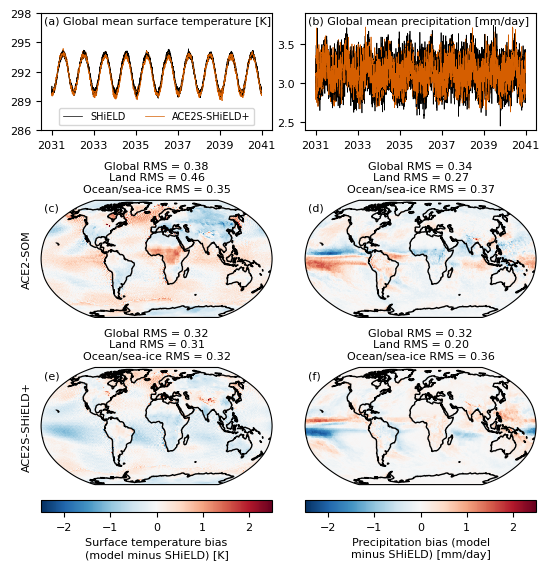

In [13]:
plotting.configure_style()

fig, (ax5, ax6, ax3, ax4, ax1, ax2), (cax1, cax2) = plotting.width_constrained_plot(
    3,
    2,
    5.5,
    aspect,
    cbar_pad=0.15,
    horizontal_pads=[0.33],
    vertical_pads=[0.5, 0.7],
    left_pad=0.4,
    bottom_pad=0.6,
    top_pad=0.1,
    right_pad=0.15,
    axes_kwargs={"projection": ccrs.Robinson()},
)

# Remove projection from axes[0] and axes[1].
position = ax1.get_position(original=True)
ax1.set_visible(False)
ax1 = fig.add_axes(position)

position = ax2.get_position(original=True)
ax2.set_visible(False)
ax2 = fig.add_axes(position)

for initial_condition in time_series.initial_condition:
    if initial_condition.item() == 1:
        label_shield = "SHiELD"
        label_ace = "ACE2S-SHiELD+"
    else:
        label_shield = None
        label_ace = None
    time_series.sel(
        model="SHiELD-SOM", initial_condition=initial_condition
    ).surface_temperature.plot(ax=ax1, color="k", lw=0.5, label=label_shield)
    time_series.sel(
        model="full energy-conserving rs0", initial_condition=initial_condition
    ).surface_temperature.plot(ax=ax1, color="C4", lw=0.5, label=label_ace)

for initial_condition in time_series.initial_condition:
    if initial_condition.item() == 1:
        label_shield = "SHiELD"
        label_ace = textwrap.fill("ACE2S-SOM w/ random CO$_2$ w/ energy conservation", width=25)
    else:
        label_shield = None
        label_ace = None
    time_series.sel(
        model="SHiELD-SOM", initial_condition=initial_condition
    ).PRATEsfc.plot(ax=ax2, color="k", lw=0.5, label=label_shield)
    time_series.sel(
        model="full energy-conserving rs0", initial_condition=initial_condition
    ).PRATEsfc.plot(ax=ax2, color="C4", lw=0.5, label=label_ace)


ax1.set_ylim(286, 298)
ax2.set_ylim(2.4, 3.9)

ax1.set_yticks([286, 289, 292, 295, 298])

ax1.set_title("")
ax2.set_title("")

for ax in (ax1, ax2):
    ax.set_xticks(xr.date_range("2031", "2041", freq="2YS"))
    ax.set_xlabel("")
    ax.set_ylabel("")

ax1.annotate(
    "(a) Global mean surface temperature [K]",
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)
ax2.annotate(
    "(b) Global mean precipitation [mm/day]",
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)

ax1.legend(ncol=2, fontsize=7, loc="lower center")

vmin, vmax = -2.5, 2.5
cmap = "RdBu_r"
p1 = time_mean_bias.sel(
    model="ACE2-SOM", climate="3xCO2"
).surface_temperature.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)
p1 = time_mean_bias .sel(
    model="full-energy-conserving-rs0", climate="3xCO2"
).surface_temperature.plot(
    ax=ax5,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)

ax3.set_title(
    get_title(
        rmse, "surface_temperature", "3xCO2", "ACE2-SOM", "RMS"
    )
)
ax5.set_title(
    get_title(
        rmse, "surface_temperature", "3xCO2", "full-energy-conserving-rs0", "RMS"
    )
)

vmin, vmax = -2.5, 2.5
cmap = "RdBu_r"
p2 = time_mean_bias.sel(model="ACE2-SOM", climate="3xCO2").PRATEsfc.plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)
p2 = time_mean_bias.sel(model="full-energy-conserving-rs0", climate="3xCO2").PRATEsfc.plot(
    ax=ax6,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)

ax4.set_title(
    get_title(
        rmse, "PRATEsfc", "3xCO2", "ACE2-SOM", "RMS"
    )
)
ax6.set_title(
    get_title(
        rmse, "PRATEsfc", "3xCO2", "full-energy-conserving-rs0", "RMS"
    )
)

for ax in (ax3, ax4, ax5, ax6):
    ax.coastlines()

ax3.annotate(
    "ACE2-SOM",
    xy=(0, 0.5),
    xytext=(-10, 0),
    xycoords="axes fraction",
    textcoords="offset points",
    ha="center",
    va="center",
    rotation=90,
)
ax5.annotate(
    textwrap.fill("ACE2S-SHiELD+", width=25),
    xy=(0, 0.5),
    xytext=(-10, 0),
    xycoords="axes fraction",
    textcoords="offset points",
    ha="center",
    va="center",
    rotation=90,
)

for ax, label in zip((ax3, ax4, ax5, ax6), ("c", "d", "e", "f")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.colorbar(
    p1,
    cax=cax1,
    orientation="horizontal",
    label=textwrap.fill("Surface temperature bias (model minus SHiELD) [K]", width=30),
)

fig.colorbar(
    p2,
    cax=cax2,
    orientation="horizontal",
    label=textwrap.fill("Precipitation bias (model minus SHiELD) [mm/day]", width=30),
)

fig.patch.set_alpha(0.0)
fig.savefig("figure-03.png", dpi=300)
fig.savefig("figure-03.pdf")
